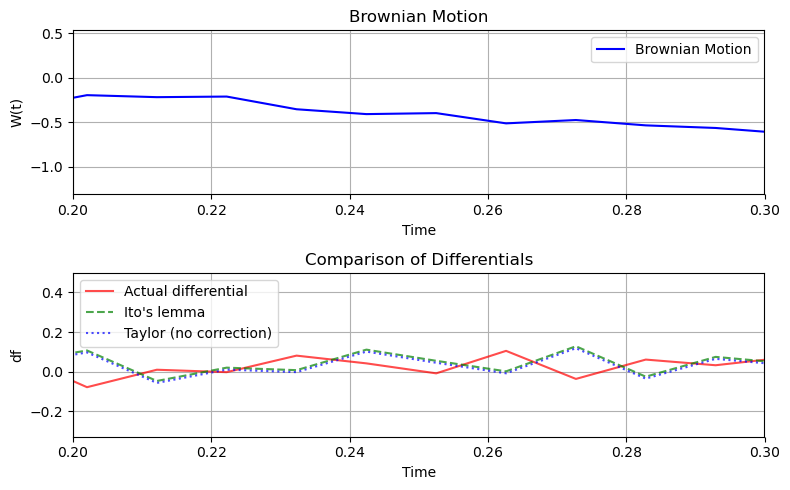

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Simulation parameters
T = 1.0  # Total time
N = 100  # Number of steps
dt = T/N  # Time step
t = np.linspace(0, T, N)

# Simulate Brownian motion
dW = np.random.normal(0, np.sqrt(dt), N)
W = np.cumsum(dW)

# Function f(t,W) = W^2
f = W**2

# Compute differentials using Ito's lemma
# df = 2W dW + dt (Ito's lemma with correction term)
df_ito = 2*W*dW + dt

# Compute Taylor differential without correction term
# df = 2W dW (standard Taylor expansion)
df_taylor = 2*W*dW

# Compute actual differential
df_actual = np.diff(f)

# Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5))

# Plot Brownian motion
ax1.plot(t, W, 'b-', label='Brownian Motion')
ax1.set_title('Brownian Motion')
ax1.set_xlabel('Time')
ax1.set_ylabel('W(t)')
ax1.grid(True)
ax1.legend()
# Zoom in to time interval [0.2, 0.3]
ax1.set_xlim(0.2, 0.3)

# Plot differentials
ax2.plot(t[1:], df_actual, 'r-', label='Actual differential', alpha=0.7)
ax2.plot(t[1:], df_ito[:-1], 'g--', label="Ito's lemma", alpha=0.7)
ax2.plot(t[1:], df_taylor[:-1], 'b:', label='Taylor (no correction)', alpha=0.7)
ax2.set_title("Comparison of Differentials")
ax2.set_xlabel('Time')
ax2.set_ylabel('df')
ax2.grid(True)
ax2.legend()
# Zoom in to same time interval for comparison
ax2.set_xlim(0.2, 0.3)

plt.tight_layout()
plt.show()

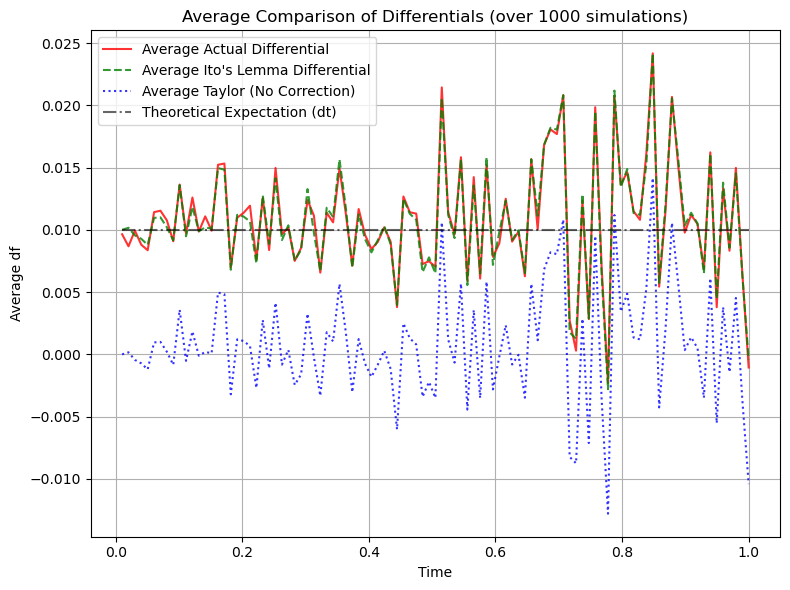

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Simulation parameters
T = 1.0  # Total time
N = 100  # Number of steps
dt = T / N  # Time step
t = np.linspace(0, T, N)

# Number of simulations to average over
num_simulations = 1000 # Increased for better averaging

# Initialize arrays to store sums for averaging
sum_df_ito = np.zeros(N)
sum_df_taylor = np.zeros(N)
sum_df_actual = np.zeros(N-1) # Actual differential has N-1 points

# Run multiple simulations
for _ in range(num_simulations):
    dW = np.random.normal(0, np.sqrt(dt), N)# Simulate Brownian motion
    # W needs to be simulated with an initial value, typically W_0 = 0
    W = np.insert(np.cumsum(dW[:-1]), 0, 0) # W_0=0, then cumulative sum up to N-1
                                           # This makes W and dW consistent for the differential calculation
    
    # Function f(W) = W^2 (note: your original f=W^2 had N points, but dW had N points.
    # To align them for 2*W*dW, W needs to be the 'left' value.)
    f_val = W**2 # f(W_t)

    # Compute differentials using Ito's lemma
    # df = 2W dW + dt
    df_ito_single_path = 2 * W[:-1] * dW[:-1] + dt # Use W_t and dW_t

    # Compute Taylor differential without correction term
    # df = 2W dW
    df_taylor_single_path = 2 * W[:-1] * dW[:-1]

    # Compute actual differential (f(t+dt) - f(t))
    df_actual_single_path = np.diff(f_val)

    # Accumulate for averaging
    sum_df_ito += np.pad(df_ito_single_path, (0,1), 'constant', constant_values=0) # Pad with 0 to match size
    sum_df_taylor += np.pad(df_taylor_single_path, (0,1), 'constant', constant_values=0) # Pad with 0 to match size
    sum_df_actual += df_actual_single_path


# Calculate averages
avg_df_ito = sum_df_ito / num_simulations
avg_df_taylor = sum_df_taylor / num_simulations
avg_df_actual = sum_df_actual / num_simulations


# Plotting the Averages
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(t[1:], avg_df_actual, 'r-', label='Average Actual Differential', alpha=0.8)
ax.plot(t[1:], avg_df_ito[:-1], 'g--', label="Average Ito's Lemma Differential", alpha=0.8)
ax.plot(t[1:], avg_df_taylor[:-1], 'b:', label='Average Taylor (No Correction)', alpha=0.8)

# Overlay the expected value of df_actual for W_t^2, which is just dt
# E[d(W_t^2)] = E[dt + 2W_t dW_t] = dt + 2 E[W_t]E[dW_t] (since W_t and dW_t are independent and E[dW_t]=0)
# E[d(W_t^2)] = dt
ax.plot(t[1:], np.full_like(t[1:], dt), 'k-.', label='Theoretical Expectation (dt)', alpha=0.6)


ax.set_title(f"Average Comparison of Differentials (over {num_simulations} simulations)")
ax.set_xlabel('Time')
ax.set_ylabel('Average df')
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio 

# Set random seed for reproducibility
np.random.seed(42)

# Generate Brownian motion paths
def generate_brownian_path(n_steps=1000, T=1.0):
    dt = T/n_steps
    dW = np.random.normal(0, np.sqrt(dt), n_steps)
    W = np.cumsum(dW)
    W = np.insert(W, 0, 0)  # Add W₀ = 0
    t = np.linspace(0, T, n_steps + 1)
    return t, W, dW

# Generate multiple paths
n_paths = 5
paths_data = [generate_brownian_path() for _ in range(n_paths)]

# Create subplots
fig = make_subplots(rows=2, cols=1, 
                    subplot_titles=('Sample Paths of Brownian Motion', 'Increments (dW)'),
                    vertical_spacing=0.15,
                    row_heights=[0.7, 0.3])

# Colors for paths
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEEAD']

# Add each path and its increments
for i, (t, W, dW) in enumerate(paths_data):
    # Plot Brownian path
    fig.add_trace(
        go.Scatter(
            x=t,
            y=W,
            mode='lines',
            line=dict(color=colors[i], width=2),
            name=f'Sample Path {i+1}'
        ),
        row=1, col=1
    )
    
    # Plot increments
    t_increments = t[:-1]  # Remove last point since we have n-1 increments
    fig.add_trace(
        go.Scatter(
            x=t_increments,
            y=dW,
            mode='lines',
            line=dict(color=colors[i], width=1),
            name=f'Increments {i+1}',
            showlegend=False
        ),
        row=2, col=1
    )

# Update layout
fig.update_layout(
    template='plotly_dark',
    title=dict(
        text='Brownian Motion and Brownian Increments',
        x=0.5,
        font=dict(size=24)
    ),
    showlegend=True,
    hovermode='x',
    height=800  # Make plot taller to accommodate subplot
)

# Update axes
for row in [1, 2]:
    fig.update_xaxes(
        showgrid=True,
        gridwidth=1,
        zeroline=True,
        zerolinewidth=2,
        tickfont=dict(size=16),
        row=row, col=1
    )
    
    fig.update_yaxes(
        showgrid=True,
        gridwidth=1,
        zeroline=True,
        zerolinewidth=2,
        tickfont=dict(size=16),
        row=row, col=1
    )

# Update axis labels
fig.update_xaxes(title_text="Time", row=2, col=1)
fig.update_yaxes(title_text="W(t)", row=1, col=1)
fig.update_yaxes(title_text="dW", row=2, col=1)
pio.renderers.default = "iframe"
fig.show()
fig.write_html("brownian_motion_plot.html")

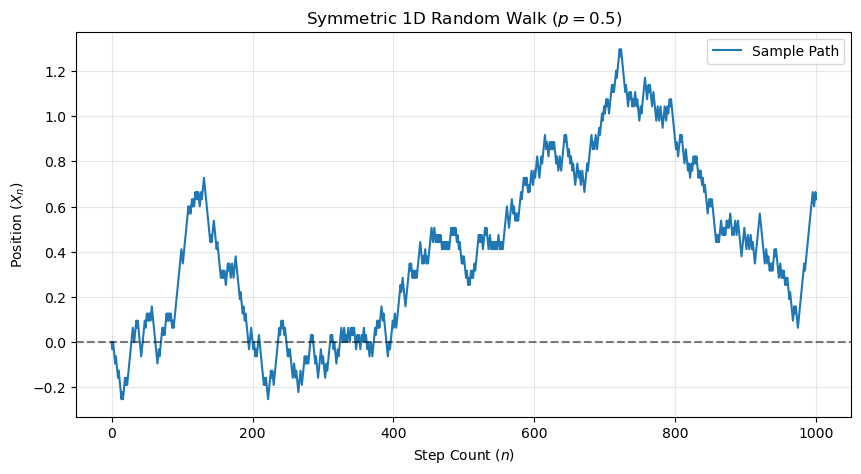

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Parameters
num_steps = 1000
start_position = 0

# Step 1: Generate random steps: +1 or -1 with equal probability (p = 0.5)
steps = np.random.choice([-1, 1], size=num_steps)
W_n = (1/np.sqrt(num_steps))*steps

# Step 2: Compute the trajectory via cumulative sum
positions_1 = np.concatenate([[start_position], np.cumsum(W_n)])
positions = np.concatenate([[start_position], np.cumsum(steps)])

# Plotting the single trajectory
plt.figure(figsize=(10, 5))
plt.plot(positions_1, label="Sample Path", color="#1f77b4", linewidth=1.5)
plt.axhline(0, color="black", linestyle="--", alpha=0.5)

plt.title("Symmetric 1D Random Walk ($p = 0.5$)")
plt.xlabel("Step Count ($n$)")
plt.ylabel("Position ($X_n$)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
    

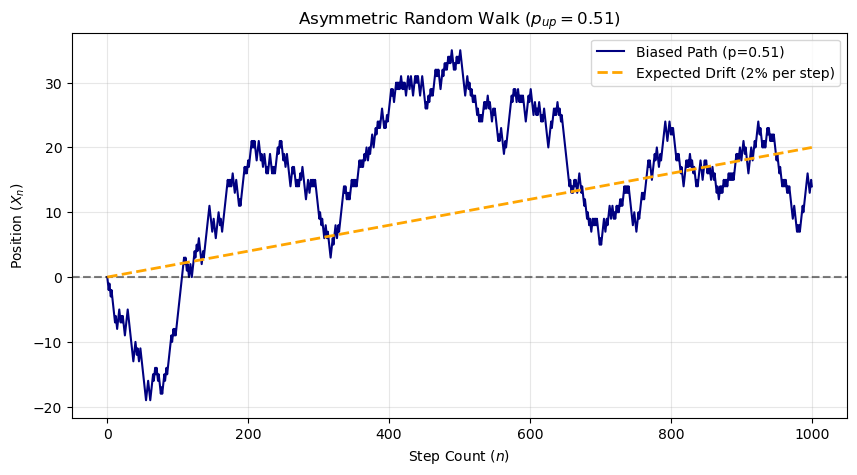

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Parameters
num_steps = 1000
p_up = 0.51  # 51% probability to move up (+1)
p_down = 1.0 - p_up  # 49% probability to move down (-1)

# Step 1: Generate random steps with custom probabilities
steps = np.random.choice([1, -1], size=num_steps, p=[p_up, p_down])

# Step 2: Compute trajectory (starting from 0)
positions = np.concatenate([[0], np.cumsum(steps)])

# Step 3: Plot the biased trajectory
plt.figure(figsize=(10, 5))
plt.plot(positions, label=f"Biased Path (p={p_up})", color="navy")
plt.axhline(0, color="black", linestyle="--", alpha=0.5)

# Expected drift line: E[X_n] = n * (p - (1-p)) = n * 0.02
expected_drift = np.arange(num_steps + 1) * (p_up - p_down)
plt.plot(
    expected_drift,
    color="orange",
    linestyle="--",
    linewidth=2,
    label="Expected Drift (2% per step)",
)

plt.title(f"Asymmetric Random Walk ($p_{{up}} = {p_up}$)")
plt.xlabel("Step Count ($n$)")
plt.ylabel("Position ($X_n$)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [8]:
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio 

# Generate time points
np.random.seed(42)
t = np.linspace(0, 1, 100)

# Simulate Brownian motion
dW = np.random.normal(0, np.sqrt(1/len(t)), len(t))
W = np.cumsum(dW)

# Create the weight surface
T, B = np.meshgrid(t, np.linspace(min(W)-0.5, max(W)+0.5, 100))
Z = T  # Weight surface is linear in time

# Create the figure
fig = go.Figure()

# Add the weight surface
fig.add_trace(go.Surface(
    x=T,
    y=B,
    z=Z,
    colorscale='Viridis',
    opacity=0.7,
    showscale=False,
    name='Weighting Function f(t,W) = t'
))

# Add the lifted path (Brownian path scaled by weight surface)
fig.add_trace(go.Scatter3d(
    x=t,
    y=W,
    z=t,  # The z-coordinate should match the surface height at (t,W)
    mode='lines',
    name='Lifted Path'
))

# Add the path on the Brownian motion/time plane (z=0)
fig.add_trace(go.Scatter3d(
    x=t,
    y=W,
    z=np.zeros_like(t),
    mode='lines',
    line=dict(color='red', width=4),
    name='Brownian Path'
))

# Add vertical projection lines at several points
projection_points = np.linspace(0, 1, 6)  # 6 evenly spaced points
for tp in projection_points:
    idx = np.abs(t - tp).argmin()
    fig.add_trace(go.Scatter3d(
        x=[t[idx], t[idx]],
        y=[W[idx], W[idx]],
        z=[0, t[idx]],  # Project to surface height
        mode='lines',
        line=dict(color='red', width=2, dash='dash'),
        showlegend=False
    ))

    ito_integral = np.cumsum(t * dW)  # Approximate Itô integral
fig.add_trace(go.Scatter3d(
    x=t,
    y=np.zeros_like(t),
    z=ito_integral,
    mode='lines',
    line=dict(color='orange', width=4),
    name='Itô Integral Value'
))


# Update layout
fig.update_layout(
    title='Itô Integration as a Lifted Path onto a Surface Weight',
    scene=dict(
        xaxis_title='Time',
        yaxis_title='Brownian Motion',
        zaxis_title='Weight',
        camera=dict(
            eye=dict(x=1, y=1.5, z=0.4)
        )  
    ),
    showlegend=True,
    width=1000,
    height=500, # White text
)
pio.renderers.default = "iframe"
fig.show()
fig.write_html("Ito_integral_plot.html")

In [5]:
def black_scholes_call(S0, K, T, r, sigma):
    from scipy.stats import norm
    import numpy as np
    d1 = (np.log(S0/K) + (r + sigma**2/2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

In [6]:
black_scholes_call(78.0517,80,1,0.07,0.25)

9.446169851929433

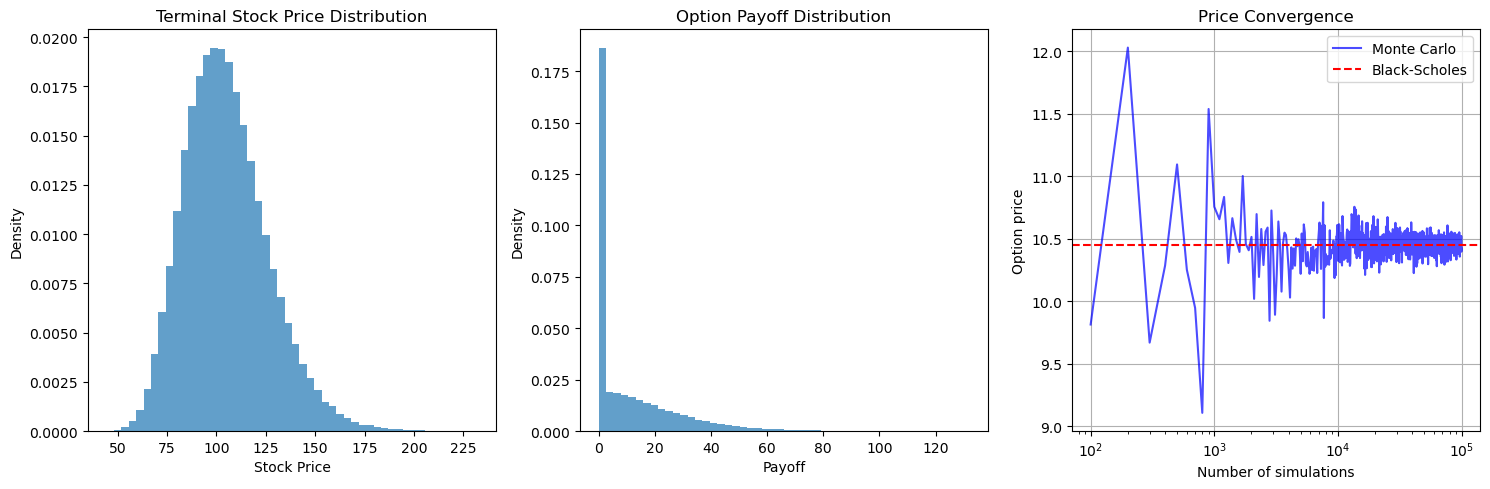

In [10]:
from scipy import stats
# Generate terminal stock prices and payoffs

n_simulations = 100000
S0, K, T, r, sigma = 100, 100, 1, 0.05, 0.2  # Parameters from interactive widgets
Z = np.random.standard_normal(n_simulations)
ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
payoffs = np.maximum(ST - K, 0)
mc_price = np.exp(-r * T) * np.mean(payoffs)
bs_price = black_scholes_call(S0, K, T, r, sigma)

# Create subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Terminal price distribution
ax1.hist(ST, bins=50, density=True, alpha=0.7)
ax1.set_title('Terminal Stock Price Distribution')
ax1.set_xlabel('Stock Price')
ax1.set_ylabel('Density')

# Plot 2: Payoff distribution
ax2.hist(payoffs, bins=50, density=True, alpha=0.7)
ax2.set_title('Option Payoff Distribution')
ax2.set_xlabel('Payoff')
ax2.set_ylabel('Density')

# Plot 3: Convergence analysis
n_steps = 10000  # Number of points to plot
step_size = 100  # Increment by 100 simulations each time
n_simulations_list = np.arange(100, 100000, step_size)
mc_prices = []

for n in n_simulations_list:
    Z = np.random.standard_normal(n)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    payoffs = np.maximum(ST - K, 0)
    mc_prices.append(np.exp(-r * T) * np.mean(payoffs))

ax3.semilogx(n_simulations_list, mc_prices, 'b-', alpha=0.7, label='Monte Carlo')
ax3.axhline(y=bs_price, color='r', linestyle='--', label='Black-Scholes')
ax3.set_xlabel('Number of simulations')
ax3.set_ylabel('Option price')
ax3.set_title('Price Convergence')
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()


In [7]:
from scipy.stats import norm
import plotly.graph_objects as go
import plotly.io as pio

# Parameters for option pricing
S0 = np.random.normal(100,10)  # Initial stock price
K = 110   # Strike price
r = 0.05  # Risk-free rate
sigma = 0.2  # Volatility
T = 1.0    # Time to maturity
n_samples = 100000  # Number of Monte Carlo samples

# Black-Scholes analytical price
d1 = (np.log(S0/K) + (r + sigma**2/2)*T) / (sigma*np.sqrt(T))
d2 = d1 - sigma*np.sqrt(T)
bs_call = S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

# Monte Carlo price using terminal distribution
Z = np.random.normal(0, 1, n_samples)
ST = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
payoffs = np.maximum(ST - K, 0)
mc_call = np.exp(-r*T) * np.mean(payoffs)

# Calculate 95% confidence interval for MC
std_error = np.std(payoffs) / np.sqrt(n_samples)
ci_lower = np.exp(-r*T) * (np.mean(payoffs) - 1.96 * std_error)
ci_upper = np.exp(-r*T) * (np.mean(payoffs) + 1.96 * std_error)

print(f"Black-Scholes Call Price: ${bs_call:.2f}")
print(f"Monte Carlo Call Price: ${mc_call:.2f}")
print(f"95% CI: (${ci_lower:.2f}, ${ci_upper:.2f})")

# Create histogram of terminal prices
fig = go.Figure()

fig.add_trace(go.Histogram(
    x=ST,
    nbinsx=50,
    name='Terminal Price Distribution',
    marker_color='rgba(0, 191, 255, 0.6)',
    histnorm='probability density'
))

# Add vertical lines for important prices
fig.add_vline(
    x=K,
    line_dash="dash",
    line_color="red",
    annotation_text=f"Strike: {K}",
    annotation_position="top right"
)

fig.add_vline(
    x=S0,
    line_dash="dash",
    line_color="green",
    annotation_text=f"Initial Price: {S0}",
    annotation_position="top left"
)

# Add theoretical lognormal density
x = np.linspace(max(0, min(ST)), max(ST), 1000)
pdf = np.exp(-(np.log(x) - (np.log(S0) + (r - 0.5*sigma**2)*T))**2 / (2*sigma**2*T)) / (x*sigma*np.sqrt(2*np.pi*T))

fig.add_trace(go.Scatter(
    x=x,
    y=pdf,
    mode='lines',
    name='Theoretical Density',
    line=dict(color='white', width=2)
))



fig.update_xaxes(
    title_text='Stock Price',
    showgrid=True,
    gridwidth=1,
    gridcolor='rgba(128,128,128,0.2)',
    zeroline=True,
    zerolinewidth=1,
    zerolinecolor='rgba(128,128,128,0.5)'
)

fig.update_yaxes(
    title_text='Density',
    showgrid=True,
    gridwidth=1,
    gridcolor='rgba(128,128,128,0.2)',
    zeroline=True,
    zerolinewidth=1,
    zerolinecolor='rgba(128,128,128,0.5)'
)
pio.renderers.default = "iframe"
fig.show()
fig.write_html("Monte_Carlo_Black_Scholes_plot.html")

Black-Scholes Call Price: $1.82
Monte Carlo Call Price: $1.81
95% CI: ($1.77, $1.85)


In [6]:
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio

def sip_monte_carlo_paths_interactive(
    monthly_investment=10000,
    years=10,
    annual_return=0.12,
    annual_volatility=0.15,
    n_simulations=500
):
    # --- Derived monthly parameters ---
    months = years * 12
    monthly_return_mean = (1 + annual_return)**(1/12) - 1
    monthly_volatility = annual_volatility / np.sqrt(12)
    
    # --- Storage for all simulations ---
    all_paths = np.zeros((n_simulations, months))
    
    for i in range(n_simulations):
        portfolio_value = 0
        monthly_values = []
        monthly_returns = np.random.normal(monthly_return_mean, monthly_volatility, months)
        
        for r in monthly_returns:
            portfolio_value = portfolio_value * (1 + r)
            portfolio_value += monthly_investment
            monthly_values.append(portfolio_value)
        
        all_paths[i, :] = monthly_values
    
    mean_path = np.mean(all_paths, axis=0)
    months_array = np.arange(1, months + 1)

    # --- Create interactive Plotly figure ---
    fig = go.Figure()

    # Add a few sample simulation paths (50 max for clarity)
    for i in range(min(n_simulations, 50)):
        fig.add_trace(
            go.Scatter(
                x=months_array,
                y=all_paths[i],
                mode='lines',
                line=dict(color='skyblue', width=1),
                opacity=0.3,
                name=f'Simulation {i+1}' if i < 3 else None,  # only label few
                showlegend=False if i >= 3 else True
            )
        )

    # Add mean path
    fig.add_trace(
        go.Scatter(
            x=months_array,
            y=mean_path,
            mode='lines',
            line=dict(color='white', width=1.5),
            name='Expected Mean Path'
        )
    )

    # --- Annotations & layout ---
    fig.update_layout(
        title=f"SIP Monte Carlo Simulation ({years} years, ₹{monthly_investment}/month)",
        xaxis_title="Months",
        yaxis_title="Portfolio Value (₹)",
        template='plotly_dark',
        hovermode='x',
        showlegend=True,
        legend=dict(x=0.02, y=0.95),
        height=600
    )

    # Add text annotation for expected final value
    fig.add_annotation(
        x=months,
        y=mean_path[-1],
        text=f"Expected Final Value ≈ ₹{mean_path[-1]:,.0f}",
        showarrow=True,
        arrowhead=2,
        ax=-50,
        ay=-40,
        bgcolor="black",
        bordercolor="red"
    )

    # Enable zoom, pan, and autoscale buttons
    fig.update_layout(
        xaxis=dict(rangeslider=dict(visible=True)),  # adds zoom slider below x-axis
        dragmode='zoom'
    )
    pio.renderers.default = "iframe"
    fig.show()
    fig.write_html("SIP_monte_carlo.html")

    # --- Summary statistics ---
    print(f"Expected Final Portfolio Value: ₹{mean_path[-1]:,.0f}")
    return mean_path, all_paths

# --- Run the simulation ---
mean_path, all_paths = sip_monte_carlo_paths_interactive(
    monthly_investment=10000,  # ₹10,000 per month
    years=10,                  # 10 years
    annual_return=0.12,        # 12% expected annual return
    annual_volatility=0.15,    # 15% annual volatility
    n_simulations=500          # number of simulation paths
)

Expected Final Portfolio Value: ₹2,216,931


In [5]:
# Read in APPL returns data
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
import yfinance as yf

# Getting the data for Apple
ticker_symbol = "AAPL"
stock = yf.Ticker(ticker_symbol)
data = stock.history(period="2y")
df = data.copy()
df = df.reset_index()

# Calculate daily returns
df['Returns'] = df['Close'].pct_change()

# Remove the first row which will have NaN return
df = df.dropna()

# Get sample mean and std as MLE estimates
mu_hat = df['Returns'].mean()
sigma_hat = df['Returns'].std()

# Generate points for fitted normal distribution
x_fit = np.linspace(mu_hat - 4*sigma_hat, mu_hat + 4*sigma_hat, 1000)
y_fit = 1/(sigma_hat * np.sqrt(2*np.pi)) * np.exp(-(x_fit - mu_hat)**2/(2*sigma_hat**2))

# Create figure with secondary y-axis
fig = make_subplots(rows=2, cols=1, vertical_spacing=0.15, 
                    subplot_titles=("APPL Returns with Fitted Normal Distribution", 
                                  "Empirical Rule of the Normal Distribution"))

# Add histogram of returns
fig.add_trace(
    go.Histogram(
        x=df['Returns'],
        name='APPL Returns',
        nbinsx=50,
        histnorm='probability density'
    ),
    row=1, col=1
)

# Add fitted normal distribution curve
fig.add_trace(
    go.Scatter(
        x=x_fit,
        y=y_fit,
        mode='lines',
        line=dict(color='rgba(255, 0, 255, 1)', width=2),
        name='Fitted Normal'
    ),
    row=1, col=1
)

# Add vertical lines for standard deviations in first subplot
for n in [-4, -3, -2, -1, 1, 2, 3, 4]:
    fig.add_shape(
        type="line",
        x0=mu_hat + n*sigma_hat,
        x1=mu_hat + n*sigma_hat,
        y0=0,
        y1=30,
        line=dict(color='rgba(128,128,128,0.5)', width=1, dash='dash'),
        row=1, col=1
    )

# Add empirical rule plot
mu = 0
sigma = 1
x_emp = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 500)
y_emp = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_emp - mu) / sigma) ** 2)

# Add main curve to second subplot
fig.add_trace(
    go.Scatter(
        x=x_emp,
        y=y_emp,
        mode='lines',
        line=dict(color='rgba(0, 255, 255, 1)', width=2),
        name='Normal Distribution',
        showlegend=False
    ),
    row=2, col=1
)

# Define ranges for empirical rule with neon colors
ranges = [
    (mu - 1 * sigma, mu + 1 * sigma, '34%', 'rgba(255, 0, 255, 0.3)'),
    (mu - 2 * sigma, mu + 2 * sigma, '47.5%', 'rgba(0, 255, 0, 0.3)'),
    (mu - 3 * sigma, mu + 3 * sigma, '49%', 'rgba(255, 255, 0, 0.3)')
]

# Add shaded regions for empirical rule
for start, end, label, color in reversed(ranges):
    mask = (x_emp >= start) & (x_emp <= end)
    x_fill = x_emp[mask]
    y_fill = y_emp[mask]
    
    fig.add_trace(
        go.Scatter(
            x=np.concatenate([x_fill, x_fill[::-1]]),
            y=np.concatenate([y_fill, np.zeros_like(y_fill)]),
            fill='toself',
            fillcolor=color,
            opacity=0.4,
            line=dict(width=0),
            name=f'{label} Rule',
            showlegend=False
        ),
        row=2, col=1
    )
    
    # Add percentage text annotations
    fig.add_annotation(
        x=start + 0.5,
        y=0.2,
        text=label,
        showarrow=False,
        font=dict(size=14, color='black'),
        row=2,
        col=1
    )
    fig.add_annotation(
        x=end - 0.5,
        y=0.2,
        text=label,
        showarrow=False,
        font=dict(size=14, color='black'),
        row=2,
        col=1
    )
    
    # Add vertical lines for standard deviations
    fig.add_shape(
        type="line",
        x0=start, x1=start,
        y0=-0.1, y1=1.0,
        line=dict(color='rgba(128,128,128,0.5)', width=1, dash='dash'),
        row=2, col=1
    )
    fig.add_shape(
        type="line",
        x0=end, x1=end,
        y0=-0.1, y1=1.0,
        line=dict(color='rgba(128,128,128,0.5)', width=1, dash='dash'),
        row=2, col=1
    )

# Update layout
fig.update_layout(
    height=800,
    width=1100,
    showlegend=True,
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    font=dict(color='black')
)

# Update axes for both subplots
fig.update_xaxes(
    title='Returns',
    showgrid=True,
    gridwidth=1,
    gridcolor='rgba(128,128,128,0.2)',
    zeroline=True,
    zerolinewidth=1,
    zerolinecolor='rgba(128,128,128,0.5)',
    row=1, col=1
)
fig.update_yaxes(
    title='Density',
    showgrid=True,
    gridwidth=1,
    gridcolor='rgba(128,128,128,0.2)',
    zeroline=True,
    zerolinewidth=1,
    zerolinecolor='rgba(128,128,128,0.5)',
    row=1, col=1
)

# Update second subplot axes
fig.update_xaxes(
    title='X',
    showgrid=True,
    gridwidth=1,
    gridcolor='rgba(128,128,128,0.2)',
    zeroline=True,
    zerolinewidth=1,
    zerolinecolor='rgba(128,128,128,0.5)',
    row=2, col=1
)
fig.update_yaxes(
    title='Probability Density',
    showgrid=True,
    gridwidth=1,
    gridcolor='rgba(128,128,128,0.2)',
    zeroline=True,
    zerolinewidth=1,
    zerolinecolor='rgba(128,128,128,0.5)',
    range=[-0.1, 0.5],
    row=2, col=1
)
pio.renderers.default = "iframe"
fig.show()
fig.write_html("apple_returns_normal_dist_plot.html")

In [4]:
# Read in AAPL data and calculate returns
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
import yfinance as yf
ticker_symbol = "AAPL"
stock = yf.Ticker(ticker_symbol)
data = stock.history(period="2y")
df = data.copy()
df = df.reset_index()
df['Date'] = pd.to_datetime(df['Date'])  # Convert to datetime
df = df.sort_values('Date')  # Sort chronologically
df['Returns'] = df['Close'].pct_change(fill_method=None)
df = df.dropna()

# Filter for 2024-2025 only
df = df[(df['Date'].dt.year >= 2024) & (df['Date'].dt.year <= 2025)]

# Calculate realized volatility using two different windows
df['RV_20'] = df['Returns'].rolling(window=20).std() * np.sqrt(252)  # 20-day rolling vol
df['RV_60'] = df['Returns'].rolling(window=60).std() * np.sqrt(252)  # 60-day rolling vol

# Drop initial NaN values from warmup period
df = df.dropna()

# Create figure
fig = go.Figure()

# Add 20-day volatility
fig.add_trace(
    go.Scatter(
        x=df['Date'],
        y=df['RV_20'],
        name='20-Day Rolling Volatility',
        line=dict(color='rgba(0, 255, 0, 1)', width=2)  # Neon green
    )
)

# Add 60-day volatility
fig.add_trace(
    go.Scatter(
        x=df['Date'],
        y=df['RV_60'],
        name='60-Day Rolling Volatility',
        line=dict(color='rgba(255, 0, 255, 1)', width=2)  # Neon pink
    )
)

# Update layout
fig.update_layout(
    title='AAPL Realized Volatility: 20-Day vs 60-Day Rolling Windows',
    xaxis_title='Date',
    yaxis_title='Annualized Volatility',
    height=500,
    width=1000,
    showlegend=True,
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    font=dict(color='black')
)

# Update axes
fig.update_xaxes(
    showgrid=True,
    gridwidth=1,
    gridcolor='rgba(128,128,128,0.2)',
    zeroline=False,
    zerolinewidth=1,
    zerolinecolor='rgba(128,128,128,0.5)',
    dtick='M3'  # Show ticks every quarter
)

fig.update_yaxes(
    showgrid=True,
    gridwidth=1,
    gridcolor='rgba(128,128,128,0.2)',
    zeroline=False,
    zerolinewidth=1,
    zerolinecolor='rgba(128,128,128,0.5)'
)
pio.renderers.default = "iframe"
fig.show()
fig.write_html("apple_rolling_volatility_plot.html")

In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
from scipy.stats import gaussian_kde
import yfinance as yf

# Call the data
ticker_symbol = "AAPL"
stock = yf.Ticker(ticker_symbol)
data = stock.history(period="2y")
df = data.copy()
df = df.reset_index()
df = df.sort_values('Date', ascending=True)  # Sort by date ascending before calculating returns
df['Returns'] = df['Close'].pct_change()
df = df.dropna()

# Create two time periods
period1 = df[(df['Date'] >= '2025-01-01') & (df['Date'] <= '2025-04-08')]
period2 = df[(df['Date'] >= '2024-09-01') & (df['Date'] <= '2024-12-31')]

# Calculate means
mean1 = period1['Returns'].mean()
mean2 = period2['Returns'].mean()

# Fit KDE for both periods
kde1 = gaussian_kde(period1['Returns'])
kde2 = gaussian_kde(period2['Returns'])

# Generate points for KDE plots
x1 = np.linspace(period1['Returns'].min(), period1['Returns'].max(), 1000)
y1 = kde1(x1)

x2 = np.linspace(period2['Returns'].min(), period2['Returns'].max(), 1000)
y2 = kde2(x2)

# Create subplots
fig = make_subplots(rows=1, cols=2, 
                    subplot_titles=("Jan-May 2025 Returns Distribution", 
                                  "Sept-Dec 2024 Returns Distribution"))

# First subplot
fig.add_trace(
    go.Scatter(
        x=x1,
        y=y1,
        mode='lines',
        line=dict(color='rgba(0, 255, 0, 1)', width=2),
        name='KDE 2025'
    ),
    row=1, col=1
)

# Add mean line for first subplot
fig.add_shape(
    type="line",
    x0=mean1,
    x1=mean1,
    y0=0,
    y1=max(y1)*1.2,  # Extend beyond the plot
    line=dict(
        color='red' if mean1 < 0 else 'green',
        width=2,
        dash='dash'
    ),
    row=1, col=1
)

# Second subplot
fig.add_trace(
    go.Scatter(
        x=x2,
        y=y2,
        mode='lines',
        line=dict(color='rgba(255, 0, 255, 1)', width=2),
        name='KDE 2024'
    ),
    row=1, col=2
)

# Add mean line for second subplot
fig.add_shape(
    type="line",
    x0=mean2,
    x1=mean2,
    y0=0,
    y1=max(y2)*1.2,  # Extend beyond the plot
    line=dict(
        color='red' if mean2 < 0 else 'green',
        width=2,
        dash='dash'
    ),
    row=1, col=2
)

# Update layout
fig.update_layout(
    height=500,
    width=1100,
    showlegend=True,
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    font=dict(color='black')
)

# Update axes
for i in [1, 2]:
    fig.update_xaxes(
        title='Returns',
        showgrid=True,
        gridwidth=1,
        gridcolor='rgba(128,128,128,0.2)',
        zeroline=True,
        zerolinewidth=1,
        zerolinecolor='rgba(128,128,128,0.5)',
        row=1, col=i
    )
    fig.update_yaxes(
        title='Density',
        showgrid=True,
        gridwidth=1,
        gridcolor='rgba(128,128,128,0.2)',
        zeroline=True,
        zerolinewidth=1,
        zerolinecolor='rgba(128,128,128,0.5)',
        row=1, col=i
    )
pio.renderers.default = "iframe"
fig.show()
fig.write_html("apple_returns_plot.html")

In [3]:
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio

# --- Calculate rolling volatility ---
window = 20  # 20-day rolling window
df['Volatility'] = df['Returns'].rolling(window=window).std() * np.sqrt(252)  # Annualized

# Volatility thresholds
vol_33 = df['Volatility'].quantile(0.33)
vol_66 = df['Volatility'].quantile(0.66)

# Volatility regimes
df['Regime'] = 'Medium'
df.loc[df['Volatility'] <= vol_33, 'Regime'] = 'Low'
df.loc[df['Volatility'] >= vol_66, 'Regime'] = 'High'

# --- Create figure ---
fig = go.Figure()

# Regime colors
regime_colors = {
    'Low': 'rgb(0,255,0)',
    'Medium': 'rgb(255,255,0)',
    'High': 'rgb(255,0,0)'
}

# --- Build continuous segments ---
dates = df['Date'].values
prices = df['Close'].values
regimes = df['Regime'].values

for i in range(len(df) - 1):
    x = [dates[i], dates[i+1]]
    y = [prices[i], prices[i+1]]
    regime = regimes[i]

    fig.add_trace(
        go.Scatter(
            x=x,
            y=y,
            mode="lines",
            line=dict(color=regime_colors[regime], width=2),
            name=f"{regime} Volatility",
            showlegend=(i == 0 or regime not in regimes[:i])  # Show each legend item once
        )
    )

# --- Layout ---
fig.update_layout(
    title='AAPL Price Colored by Volatility Regimes',
    height=600,
    width=1100,
    showlegend=True,
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    font=dict(color='black'),
    xaxis=dict(
        title='Date',
        showgrid=True,
        gridwidth=1,
        gridcolor='rgba(128,128,128,0.2)',
        zeroline=True,
        zerolinewidth=1,
        zerolinecolor='rgba(128,128,128,0.5)'
    ),
    yaxis=dict(
        title='Price',
        showgrid=True,
        gridwidth=1,
        gridcolor='rgba(128,128,128,0.2)',
        zeroline=True,
        zerolinewidth=1,
        zerolinecolor='rgba(128,128,128,0.5)'
    )
)
pio.renderers.default = "iframe"
fig.show()
fig.write_html("apple_coloured_volatility_plot.html")

In [3]:
!kaleido_get_chrome

C:\Users\comviva\AppData\Local\plotly\choreographer\deps\chrome-win64\chrome.exe


In [2]:
%pip install kaleido==0.2.1

   ---------------------------------------- 0.0/65.9 MB ? eta -:--:--
   - -------------------------------------- 2.1/65.9 MB 10.7 MB/s eta 0:00:06
   --- ------------------------------------ 5.2/65.9 MB 12.7 MB/s eta 0:00:05
   ---- ----------------------------------- 7.1/65.9 MB 11.5 MB/s eta 0:00:06
   ---- ----------------------------------- 8.1/65.9 MB 9.7 MB/s eta 0:00:06
   ----- ---------------------------------- 9.4/65.9 MB 8.9 MB/s eta 0:00:07
   ------ --------------------------------- 10.2/65.9 MB 8.3 MB/s eta 0:00:07
   ------- -------------------------------- 12.3/65.9 MB 8.3 MB/s eta 0:00:07
   --------- ------------------------------ 15.2/65.9 MB 8.9 MB/s eta 0:00:06
   ---------- ----------------------------- 17.6/65.9 MB 9.1 MB/s eta 0:00:06
   ----------- ---------------------------- 19.1/65.9 MB 8.9 MB/s eta 0:00:06
   ------------ --------------------------- 21.2/65.9 MB 9.1 MB/s eta 0:00:05
   -------------- ------------------------- 23.3/65.9 MB 9.2 MB/s eta 0:00

In [12]:
pip install -U kaleido

Note: you may need to restart the kernel to use updated packages.
